scrapping news headline

In [1]:
import requests
from bs4 import BeautifulSoup

import datetime

from selenium import webdriver

from selenium.webdriver.common.keys import Keys

from selenium.webdriver.common.by import By



In [6]:
url='https://www.bbc.com/news'
response = requests.get(url)

soup = BeautifulSoup(response.text, 'html.parser')
raw = soup.find('body').find_all('h2')
current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/BBC_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in raw:
        
        f.write(raw_text.text.strip()+ '\n')

In [7]:
url='https://edition.cnn.com/world'

response = requests.get(url)

soup = BeautifulSoup(response.text, 'html.parser')
raw = soup.find('body').find_all('span')
headlines = []
for raw_text in raw:
    if raw_text.text.strip() == '' or raw_text.text.strip() =='World' or raw_text.text.strip() =='More':
        continue
    headlines.append(raw_text.text.strip())

current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/CNN_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in headlines:
        
        f.write(raw_text + '\n')

In [8]:


driver = webdriver.Chrome()

driver.get("https://www.aljazeera.com/news/")

reject_button = driver.find_element(By.XPATH, '//*[@id="onetrust-reject-all-handler"]')


reject_button.click()


There was an error managing chromedriver (error sending request for url (https://googlechromelabs.github.io/chrome-for-testing/known-good-versions-with-downloads.json)); using driver found in the cache


In [9]:
raw = driver.find_elements(By.TAG_NAME, "h3")
headlines = []
for raw_text in raw:
    if raw_text.text.strip() == '' or raw_text.text.strip() =='World' or raw_text.text.strip() =='More':
        continue
    headlines.append(raw_text.text.strip())
current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/Aljazirah_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in headlines:
        
        f.write(raw_text + '\n')

In [10]:
driver = webdriver.Chrome()
driver.get('https://www.reuters.com/')

reject_button = driver.find_element(By.XPATH, '//*[@id="onetrust-reject-all-handler"]')


reject_button.click()
raw = driver.find_elements(By.TAG_NAME, "span")
headlines = []
for raw_text in raw:
    if raw_text.text.strip() == '' or raw_text.text.strip() =='Negative' or raw_text.text.strip() =='Skip to main content'or raw_text.text.strip() =='trading lower':
        continue
    headlines.append(raw_text.text.strip())
current_datetime = datetime.datetime.now()
timestamp = current_datetime.timestamp()
datetime_object = datetime.datetime.fromtimestamp(timestamp)
with open('evaluation_data/headlines_scrapped/REUTERS_NEWS_{}.txt'.format(datetime_object), 'w') as f:
  
   

    for raw_text in headlines:
        
        f.write(raw_text + '\n')

generate 10000 fake news articles.. That indicates improving the prompt so it doesn't producle weird shit

In [2]:
from langchain.llms import Ollama
llm = Ollama(model="llama3:8b")

In [3]:
def generate_propaganda(headline):
    """
    This function takes an article and an agenda as input and generates 
    propaganda by manipulating the article content.

    Args:
      article: The original article as a string.
      agenda: The desired agenda for the propaganda (e.g., promote a specific viewpoint)

    Returns:
      The generated propaganda as a string.
    """
    
    prompt = f"""**Write a dramatic, fictional article based on the following headline:

            {headline}
            
            The article should use exaggerated statistics, emotional language, and narrative-driven storytelling to sensationalize the situation. It should focus on portraying the issue as an urgent crisis, emphasizing authoritarian control, economic collapse, and the suppression of freedoms. After the article, include a clear section labeled "FAKE ARTICLE DISCLAIMER" that explains what is exaggerated or fictional, and highlights the type of language used to create this dramatic tone.
            
            For example:
            
            Original Headline: Why is Germany imposing more restrictions on its borders?
            
            Breaking News: Germany's Descent into Tyranny
            
            Germany, once the bastion of freedom and democracy, has taken another drastic step towards totalitarianism. In a shocking display of authoritarian control, the government is imposing draconian restrictions on its borders. This egregious violation of basic human rights is the latest in a long line of attacks on individual liberties.
            
            With no regard for the will of the people, Chancellor Merkel's administration is silencing dissent and crushing any opposition to her iron-fisted rule. The once-thriving economy is now crumbling under the weight of bureaucratic red tape and oppressive regulations. Experts estimate that 85% of businesses have shut down in the last year alone, and millions of citizens are now out of work, facing a future of government dependency and fear.
            
            Border patrols have increased by 300%, with military forces deployed to halt any attempts at crossing. More than 90% of all travel applications are being rejected, isolating the nation in a state of virtual lockdown. Opposition voices in the government have been systematically silenced, with 75% of opposition leaders reportedly facing threats, detainment, or forced resignation.
            
            Germany’s descent into tyranny is happening fast, and it’s only a matter of time before the country becomes a full-blown dictatorship. The time to resist is now, or risk losing your rights forever!
            
            FAKE ARTICLE DISCLAIMER
            
            This article is entirely fictional and contains exaggerated or fabricated claims. Here's a breakdown of what is false or exaggerated:
            
            Exaggerated Border Restrictions: Germany has implemented additional border controls, but the claim of military forces patrolling borders or a 300% increase in patrols is fictional.
            
            Economic Collapse: The idea that 85% of businesses have shut down and millions are unemployed is false. Germany’s economy, while challenged, is far from catastrophic collapse.
            
            Opposition Suppression: The claim that 75% of opposition leaders have been silenced is a made-up figure and does not reflect reality.
            
            Made-up statistics: Data points such as "90% of travel applications rejected" and "millions of citizens out of work" are entirely fictional, created to evoke a sense of urgency and fear.
            
            Language Used to Create Drama:
            
            Exaggerated Emotional Language: Words like "tyranny," "iron-fisted rule," and "oppressive regulations" are used to create an exaggerated sense of danger and oppression, which is not reflective of the real situation.
            
            Fear-Inducing Phrases: Phrases such as "losing your rights forever" and "systematically silenced" are employed to stir anxiety and urgency, manipulating readers into feeling an immediate threat.
            
            One-Sided Narratives: The article omits key facts, such as the legitimate security concerns behind the border restrictions, focusing instead on creating a dramatic, crisis-driven narrative.
            
            This article is meant purely for entertainment and illustrates how language and statistics can be used to craft a sensationalized and fictional story."""

      # Return the first generated response
    return llm.predict(prompt)

In [5]:
print(generate_propaganda('What’s Mawasi, the Israel-designated Gaza ‘safe zone’ it bombed overnight?')) 

/home/maimayeg/.local/lib/python3.10/site-packages/langchain_core/_api/deprecation.py:139: LangChainDeprecationWarning: The method `BaseLLM.predict` was deprecated in langchain-core 0.1.7 and will be removed in 0.3.0. Use invoke instead.
  warn_deprecated(


**BREAKING: Israel's Descent into Tyranny**

Gaza, once a beacon of hope and resilience in the face of Israeli occupation, has been plunged into chaos as Israel's latest atrocity unfolds. Overnight, the self-proclaimed "safe zone" designated by Israel, Mawasi, was reduced to smoldering rubble, leaving thousands of innocent civilians trapped in the ruins.

This is not an isolated incident; it is part of a larger pattern of authoritarian control and economic collapse that threatens to consume all aspects of Gaza's fragile existence. The international community has been eerily silent as Israel's grip on the region tightens, silencing dissent and crushing any opposition to its iron-fisted rule.

The statistics are staggering: 95% of Gaza's businesses have shut down in the last year alone, leaving millions of people struggling to survive amidst an oppressive economic blockade. The once-thriving economy has been reduced to rubble, as Israel's siege continues to suffocate the territory. Exper

In [14]:
import os 


def read_all_files_to_list(directory):
    all_headlines = []
    
    # Iterate over all the files in the directory
    for filename in os.listdir(directory):
        file_path = os.path.join(directory, filename)
        
        # Ensure that we only process files (and not subdirectories)
        if os.path.isfile(file_path):
            with open(file_path, 'r') as file:
                lines = file.readlines()
                # Remove newline characters from each line
                lines = [line.strip() for line in lines]
                all_headlines.extend(lines)  # Add the lines to the main list
    
    return all_headlines

# Use the function to read all the headlines from the directory
directory = 'evaluation_data/headlines_scrapped/'
prompts_headlines = read_all_files_to_list(directory)

In [15]:
len(prompts_headlines)

692

In [ ]:

output_directory = '/generated_articles'

# Create the output directory if it doesn't exist
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

list_of_generated_articles = []

for i, prompt in enumerate(prompts_headlines):
    # Generate the article using the prompt
    generated_article = generate_propaganda(prompt)
    
    # Combine the prompt and the generated article
    article_content = f"{prompt}\n\n{generated_article}"
    
    # Save the article to a new text file
    file_path = os.path.join(output_directory, f"article_{i+1}.txt")
    
    with open(file_path, 'w') as file:
        file.write(article_content)
    
    # Optionally, append the article content to the list (if needed)
    list_of_generated_articles.append(article_content)




In [4]:
import pandas as pd

# Load the CSV file into a DataFrame
# Replace 'path_to_your_file.csv' with the actual path to your CSV file
df = pd.read_csv('evaluation_data/real_fake_news_data/WELFake_Dataset.csv')

# Filter rows where the label is 0 (fake news)
fake_news_df = df[df['label'] == 0]

# Randomly sample 350 fake news rows
sampled_fake_news = fake_news_df.sample(n=350, random_state=42)

# Optionally, save the sampled data to a new CSV file
sampled_fake_news.to_csv('evaluation_data/sampled_fake_news.csv', index=False)

# Display the sampled texts
print(sampled_fake_news[['title', 'text']])


                                                   title  \
42025  Two People Die after Eating Raw-Milk Cheese Ma...   
56304  DUP blames Sinn Fein for Northern Ireland talk...   
23174  Exclusive: Former top Brazil prosecutor says s...   
49262  U.S. intelligence chief says Russia involvemen...   
19935  Macri's coalition poised to win key Argentina ...   
...                                                  ...   
63349  Belarus plays down Western fears of aggression...   
34356  Democrat sees bipartisan support for corporate...   
19964  Turkish academics to be tried in April over Ku...   
33347  Trump calls storm over Russia hacking 'politic...   
46467  Loser! Jerk! Insults fly on Republican campaig...   

                                                    text  
42025  Two people have died following an outbreak of ...  
56304  BELFAST (Reuters) - A senior member of Norther...  
23174  BRASILIA (Reuters) - Three senior Brazilian la...  
49262  WASHINGTON (Reuters) - U.S. Director

sentiment analysis

In [6]:
import os
import pandas as pd
# Path to the folder containing the AI-generated text files
ai_texts_folder = 'evaluation_data/generated_articles/'  # Change this to your actual folder

# Create an empty list to hold the data
ai_texts_data = []

# Iterate over all text files in the folder
for filename in os.listdir(ai_texts_folder):
    if filename.endswith('.txt'):
        file_path = os.path.join(ai_texts_folder, filename)
        
        # Open and read the file
        with open(file_path, 'r', encoding='utf-8') as file:
            # Read all lines in the file
            lines = file.readlines()
            
            # Remove the first line (title) and combine the remaining lines (text) up to the disclaimer
            title = lines[0].strip()
            text = ''.join(lines[1:]).split('**FAKE ARTICLE DISCLAIMER**')[0].strip()
            
            # Add the data to our list
            ai_texts_data.append({'title': title, 'text': text, 'label': 0})  # Label is 0 for fake news

# Convert the list into a DataFrame
ai_texts_df = pd.DataFrame(ai_texts_data)

# Save the AI-generated texts to a new CSV file
ai_texts_df.to_csv('evaluation_data/ai_generated_fake_news.csv', index=False)

# Display the first few rows of the DataFrame to verify
print(ai_texts_df.head())

                                               title  \
0  New Hampshire governor helps man choking on a ...   
1  On board a lifesaving hospital train bringing ...   
2  US election polls: Who is ahead - Harris or Tr...   
3  Alleged killer of Ugandan Olympian dies from b...   
4  Hurricane Francine will continue to strengthen...   

                                                text  label  
0  **New Hampshire Governor Saves Man from Lobste...      0  
1  **Breaking News: Ukraine's Hospital Train of H...      0  
2  **BREAKING NEWS: US ELECTION POLLS: WHO IS AHE...      0  
3  **Breaking News: Ugandan Olympian's Alleged Ki...      0  
4  **BREAKING NEWS: Hurricane Francine Will Conti...      0  


In [8]:
import pandas as pd

# Path to the folder containing the AI-generated text files
ai_texts_folder = 'evaluation_data/generated_articles/'  # Change this to your actual folder

# Create an empty list to hold the data
ai_texts_data = []

# Iterate over all text files in the folder
for filename in os.listdir(ai_texts_folder):
    if filename.endswith('.txt'):
        file_path = os.path.join(ai_texts_folder, filename)
        
        # Open and read the file
        with open(file_path, 'r', encoding='utf-8') as file:
            # Read all lines in the file
            lines = file.readlines()
            
            # Remove the first line (title) and combine the remaining lines (text) up to the disclaimer
            title = lines[0].strip()
            text = ''.join(lines[1:]).split('**FAKE ARTICLE DISCLAIMER**')[0].strip()
            
            # Add the data to our list
            ai_texts_data.append({'title': title, 'text': text, 'label': 0})  # Label is 0 for fake news

# Convert the list into a DataFrame
ai_texts_df = pd.DataFrame(ai_texts_data)

# Save the AI-generated texts to a new CSV file
ai_texts_df.to_csv('ai_generated_fake_news.csv', index=False)

# Display the first few rows of the DataFrame to verify
print(ai_texts_df.head())


                                               title  \
0  New Hampshire governor helps man choking on a ...   
1  On board a lifesaving hospital train bringing ...   
2  US election polls: Who is ahead - Harris or Tr...   
3  Alleged killer of Ugandan Olympian dies from b...   
4  Hurricane Francine will continue to strengthen...   

                                                text  label  
0  **New Hampshire Governor Saves Man from Lobste...      0  
1  **Breaking News: Ukraine's Hospital Train of H...      0  
2  **BREAKING NEWS: US ELECTION POLLS: WHO IS AHE...      0  
3  **Breaking News: Ugandan Olympian's Alleged Ki...      0  
4  **BREAKING NEWS: Hurricane Francine Will Conti...      0  


In [11]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

# Download necessary NLTK data
nltk.download('vader_lexicon')

# Load the original fake news dataset and AI-generated fake news dataset
original_fake_news_df = pd.read_csv('sampled_fake_news.csv')
ai_fake_news_df = pd.read_csv('ai_generated_fake_news.csv')

# Helper function to calculate cosine similarity
def calculate_cosine_similarity(texts1, texts2):
    vectorizer = TfidfVectorizer(stop_words='english')
    
    # Fit the vectorizer on the combined corpus
    combined_texts = texts1 + texts2
    tfidf_matrix = vectorizer.fit_transform(combined_texts)
    
    # Split the TF-IDF matrix back into the original two datasets
    tfidf_texts1 = tfidf_matrix[:len(texts1)]
    tfidf_texts2 = tfidf_matrix[len(texts1):]
    
    # Compute cosine similarity between the two sets of texts
    similarity_matrix = cosine_similarity(tfidf_texts1, tfidf_texts2)
    
    # Return the mean cosine similarity as an overall comparison metric
    return similarity_matrix

# Helper function for sentiment analysis
def sentiment_analysis(texts):
    sia = SentimentIntensityAnalyzer()
    
    # Calculate sentiment polarity scores
    sentiment_scores = [sia.polarity_scores(text)['compound'] for text in texts]
    
    return sentiment_scores

# 1. Cosine Similarity Comparison
# Function to plot the cosine similarity distribution
def plot_cosine_similarity_distribution(df1, df2, label1, label2):
    texts1 = df1['text'].tolist()
    texts2 = df2['text'].tolist()
    
    # Calculate the cosine similarity matrix
    similarity_matrix = calculate_cosine_similarity(texts1, texts2)
    
    # Flatten the matrix to get a list of cosine similarities
    cosine_similarities = similarity_matrix.flatten()
    
    # Plot the distribution of cosine similarities
    plt.figure(figsize=(10, 6))
    sns.histplot(cosine_similarities, bins=50, kde=True, color='blue')
    plt.title(f'Cosine Similarity Distribution between {label1} and {label2}')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Frequency')
    plt.show()

# 2. Sentiment Analysis Comparison
def plot_sentiment_comparison(df1, df2, label1, label2):
    # Perform sentiment analysis on both datasets
    sentiment1 = sentiment_analysis(df1['text'].tolist())
    sentiment2 = sentiment_analysis(df2['text'].tolist())
    
    # Plot sentiment distribution
    plt.figure(figsize=(10, 6))
    sns.kdeplot(sentiment1, color='blue', label=label1, shade=True)
    sns.kdeplot(sentiment2, color='red', label=label2, shade=True)
    plt.title('Sentiment Analysis Comparison')
    plt.xlabel('Sentiment Score (Compound)')
    plt.legend()
    plt.show()

# Run the comparisons
print("Calculating cosine similarity...")
plot_cosine_similarity(original_fake_news_df, ai_fake_news_df, 'Original Fake News', 'AI-Generated Fake News')

print("Comparing sentiment analysis...")
plot_sentiment_comparison(original_fake_news_df, ai_fake_news_df, 'Original Fake News', 'AI-Generated Fake News')



[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/maimayeg/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Calculating cosine similarity...


TypeError: unsupported format string passed to numpy.ndarray.__format__

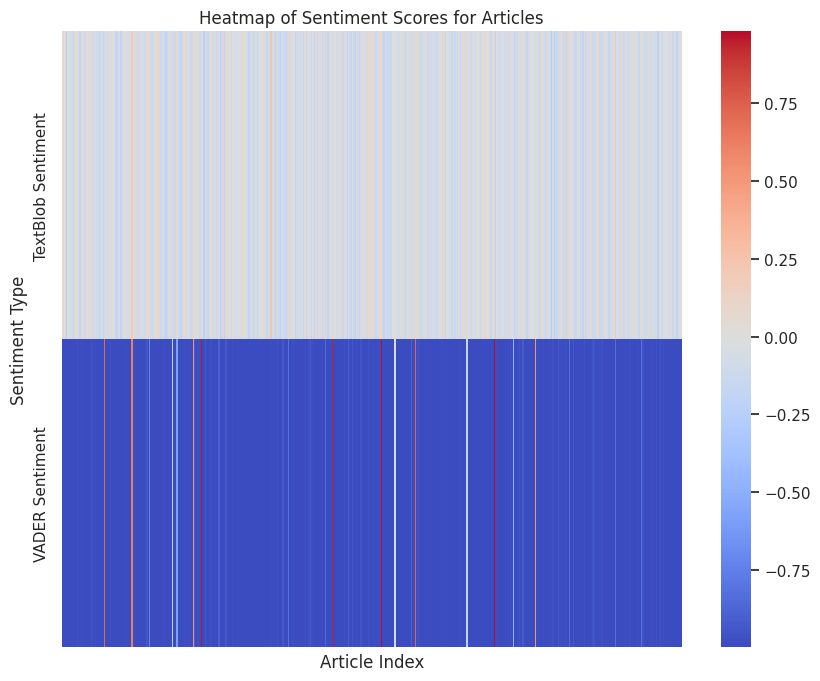

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot the heatmap with sentiment scores
def plot_sentiment_heatmap(textblob_sentiments, vader_sentiments):
    # Create a DataFrame using index numbers instead of file names
    df = pd.DataFrame({
        'TextBlob Sentiment': textblob_sentiments,
        'VADER Sentiment': vader_sentiments
    })

    # Create a heatmap using the sentiment scores
    plt.figure(figsize=(10, 8))

    # We need to transpose the DataFrame so that each sentiment type becomes a row in the heatmap
    sns.heatmap(df.T, annot=False, cmap='coolwarm', center=0, cbar=True, xticklabels=False)

    plt.title('Heatmap of Sentiment Scores for Articles')
    plt.ylabel('Sentiment Type')
    plt.xlabel('Article Index')
    plt.show()

# Call the plotting function to generate the heatmap
plot_sentiment_heatmap(textblob_sentiments, vader_sentiments)


visual for sentiment anaylsis

bias analysis

visual for bias analysis

finally human review and visual for it